# 🏈 NFL Fantasy Football Player Analysis
Analysis of player value using ADP, VORP, and isotonic regression to identify undervalued players.

## 1. Setup & Database Connection

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.isotonic import IsotonicRegression

# --- Connect to database ---
conn = sqlite3.connect('sleeper_2026.db')
print('Connected to database successfully.')

Connected to database successfully.


## 2. Load Data

In [2]:
df = pd.read_sql_query("""
    SELECT p.full_name, p.position, p.age, p.years_exp,
           a.adp_ppr,
           s.pts_ppr, s.vorp_ppr
    FROM players AS p
    JOIN adp AS a ON p.player_id = a.player_id
    JOIN season_projections AS s ON p.player_id = s.player_id
    WHERE a.adp_ppr IS NOT NULL
      AND s.vorp_ppr IS NOT NULL
    ORDER BY a.adp_ppr ASC
""", conn)

# Add round column
df['adp_ppr'] = df['adp_ppr'].astype(float)
df['Round'] = np.ceil(df['adp_ppr'] / 12).astype(int)

print(f'Loaded {len(df)} players across {df["position"].nunique()} positions.')
df.head(10)

Loaded 223 players across 4 positions.


,full_name,position,age,years_exp,adp_ppr,pts_ppr,vorp_ppr,Round
0,Bijan Robinson,RB,24.0,3,1.4,324.9,272.4,1
1,Jahmyr Gibbs,RB,24.0,3,2.9,307.9,255.4,1
2,Ja'Marr Chase,WR,26.0,5,3.4,305.1,185.6,1
3,Puka Nacua,WR,24.0,3,4.9,312.5,193.0,1
4,Jaxon Smith-Njigba,WR,24.0,3,5.4,284.6,165.1,1
5,Christian McCaffrey,RB,29.0,9,6.7,291.0,238.5,1
6,Jonathan Taylor,RB,27.0,6,7.7,272.3,219.8,1
7,James Cook,RB,26.0,4,9.7,260.8,208.3,1
8,CeeDee Lamb,WR,27.0,6,10.6,270.5,151.0,1
9,Amon-Ra St. Brown,WR,26.0,5,11.2,280.5,161.0,1


## 3. K-Means Tiering

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalize ADP and VORP before clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['adp_ppr', 'vorp_ppr']])

# Fit KMeans with 8 tiers
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['Tier'] = kmeans.fit_predict(df_scaled)

# Re-order tiers so Tier 1 = best ADP
tier_order = df.groupby('Tier')['adp_ppr'].mean().sort_values().index
tier_map = {old: new + 1 for new, old in enumerate(tier_order)}
df['Tier'] = df['Tier'].map(tier_map)

print('Tier distribution:')
print(df['Tier'].value_counts().sort_index())

Tier distribution:
Tier
1    16
2    26
3    25
4    35
5    40
6    44
7    31
8     6
Name: count, dtype: int64


C:\Users\Aidan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 4. Isotonic Regression — Value Residuals Per Position

In [4]:
def calc_residuals_linear(group):
    """Baseline: simple linear regression per position."""
    if len(group) < 2:
        group['expected_vorp_linear'] = group['vorp_ppr']
        group['residual_linear'] = 0
        return group
    slope, intercept, _, _, _ = stats.linregress(group['adp_ppr'], group['vorp_ppr'])
    group['expected_vorp_linear'] = slope * group['adp_ppr'] + intercept
    group['residual_linear'] = group['vorp_ppr'] - group['expected_vorp_linear']
    return group


def calc_residuals_isotonic(group):
    """
    Isotonic regression: enforces that higher ADP = lower expected VORP.
    Fit only on positive-VORP players to avoid late-round noise distorting the curve.
    """
    fit_group = group[group['vorp_ppr'] > 0].sort_values('adp_ppr')

    if len(fit_group) < 2:
        group['expected_vorp_iso'] = group['vorp_ppr']
        group['residual_iso'] = 0
        return group

    iso = IsotonicRegression(increasing=False, out_of_bounds='clip')
    iso.fit(fit_group['adp_ppr'], fit_group['vorp_ppr'])
    group['expected_vorp_iso'] = iso.predict(group['adp_ppr'])
    group['residual_iso'] = group['vorp_ppr'] - group['expected_vorp_iso']
    return group


df = df.groupby('position', group_keys=False).apply(calc_residuals_linear)
df = df.groupby('position', group_keys=False).apply(calc_residuals_isotonic)

# Rank within position for each method
df['rank_linear'] = df.groupby('position')['residual_linear'].rank(ascending=False)
df['rank_iso']    = df.groupby('position')['residual_iso'].rank(ascending=False)
df['rank_shift']  = (df['rank_linear'] - df['rank_iso']).abs()

print('Residuals calculated. Sample:')
df = df.sort_values(by='residual_iso', ascending=False)
df[['full_name', 'position', 'adp_ppr', 'vorp_ppr',
    'residual_linear', 'residual_iso', 'rank_linear', 'rank_iso']].head(50)


Residuals calculated. Sample:


C:\Users\Aidan\AppData\Local\Temp\ipykernel_26200\888316272.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('position', group_keys=False).apply(calc_residuals_linear)
C:\Users\Aidan\AppData\Local\Temp\ipykernel_26200\888316272.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('position', group_keys=False).apply(calc_residuals_isotonic)


,full_name,position,adp_ppr,vorp_ppr,residual_linear,residual_iso,rank_linear,rank_iso
169,Chris Rodriguez,RB,182.2,62.10,48.361560,34.825000,3.0,1.0
119,Tyler Allgeier,RB,126.2,93.80,20.369104,24.725000,10.0,2.0
30,Derrick Henry,RB,34.5,191.20,20.022707,24.100000,12.0,3.0
114,Aaron Jones,RB,122.3,89.40,11.811950,20.325000,22.0,4.0
45,Zay Flowers,WR,49.1,101.90,4.336133,19.016667,34.0,1.0
89,Chuba Hubbard,RB,97.5,121.60,17.576720,17.600000,15.0,5.0
155,Sam Darnold,QB,165.3,37.48,51.368400,16.766667,2.0,1.0
139,Jordan Mason,RB,146.6,59.50,7.814213,15.816667,26.0,6.0
177,Keaton Mitchell,RB,189.4,36.30,30.236304,15.800000,8.0,7.0
36,Garrett Wilson,WR,40.9,115.10,11.415276,14.900000,24.0,2.0


## 5. Biggest Rank Changes: Linear vs Isotonic

In [5]:
print('=== Biggest rank changes: Linear vs Isotonic ===')
df.sort_values('rank_shift', ascending=False).head(15)[
    ['full_name', 'position', 'adp_ppr', 'vorp_ppr',
     'rank_linear', 'rank_iso', 'rank_shift']
]

=== Biggest rank changes: Linear vs Isotonic ===


,full_name,position,adp_ppr,vorp_ppr,rank_linear,rank_iso,rank_shift
222,Christian Kirk,WR,241.7,-22.7,9.0,73.0,64.0
220,Devaughn Vele,WR,239.8,-15.7,7.0,66.0,59.0
213,Keenan Allen,WR,233.2,-24.5,17.0,76.0,59.0
210,Tory Horton,WR,228.7,-13.7,10.0,65.0,55.0
71,DK Metcalf,WR,80.4,63.8,65.0,11.0,54.0
211,Chris Bell,WR,231.4,-28.3,25.0,78.0,53.0
217,Jaydon Blue,RB,236.6,-7.6,6.0,58.0,52.0
43,Ladd McConkey,WR,47.8,84.1,70.0,20.0,50.0
215,Cooper Kupp,WR,235.2,-33.1,29.0,79.0,50.0
208,Ryan Flournoy,WR,227.6,-3.0,6.0,54.0,48.0


## 6. Top Undervalued Players Per Position (Isotonic)

In [6]:
# Filter to positive VORP draftable players only
df_value = df[df['vorp_ppr'] > 0].copy()

for pos in ['RB', 'WR', 'TE', 'QB']:
    pos_df = df_value[df_value['position'] == pos].sort_values('residual_iso', ascending=True)
    if pos_df.empty:
        continue
    print(f'\n=== Top Undervalued {pos}s ===')
    print(pos_df.head(10)[['full_name', 'adp_ppr', 'vorp_ppr', 'residual_iso', 'rank_iso']].to_string(index=False))


=== Top Undervalued RBs ===
     full_name  adp_ppr  vorp_ppr  residual_iso  rank_iso
Brian Robinson    113.1       9.4    -59.675000      68.0
  Kimani Vidal    181.1       3.4    -23.875000      57.0
 Braelon Allen    174.1       4.0    -23.275000      56.0
  Bucky Irving     31.6     144.8    -22.300000      55.0
Kenneth Walker     14.6     176.0    -21.833333      54.0
     RJ Harvey     57.6     106.8    -20.400000      53.0
   Tank Bigsby    187.7       4.7    -15.800000      50.0
 Isiah Pacheco    191.1       5.8    -14.600000      49.0
   Blake Corum     98.3      80.9    -13.400000      48.0
   Woody Marks    141.2      31.3    -12.383333      47.0

=== Top Undervalued WRs ===
       full_name  adp_ppr  vorp_ppr  residual_iso  rank_iso
  Jauan Jennings    135.6      12.6    -22.740000      67.0
   Jaylen Waddle     46.2      68.0    -14.883333      63.0
   Davante Adams     46.9      68.7    -14.183333      61.0
        DJ Moore     59.3      59.5    -13.500000      60.0
    

## 7. Visualization — ADP vs VORP Scatter with Isotonic Fit

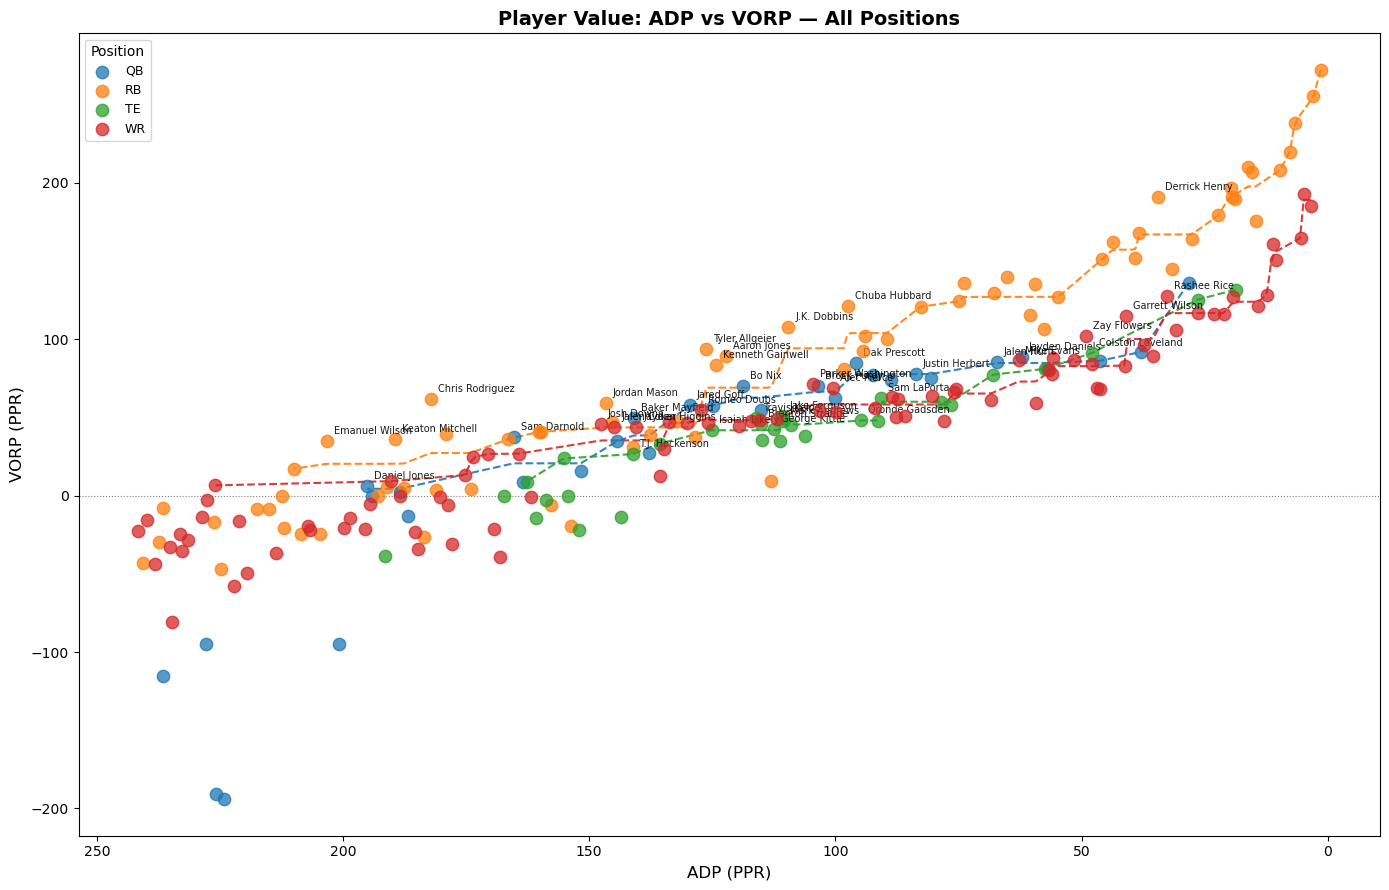

In [7]:
# ── Config ──────────────────────────────────────────────
position_filter = None   # Set to 'RB', 'WR', 'TE', 'QB' or None for all
label_top_n     = 10     # How many undervalued players to label per position
# ────────────────────────────────────────────────────────

df_plot = df[df['position'] == position_filter].copy() if position_filter else df.copy()

fig, ax = plt.subplots(figsize=(14, 9))
colors = sns.color_palette('tab10', n_colors=df['position'].nunique())
position_colors = {pos: colors[i] for i, pos in enumerate(sorted(df['position'].unique()))}

for position, group in df_plot.groupby('position'): 
    color = position_colors[position]

    # Scatter points
    ax.scatter(group['adp_ppr'], group['vorp_ppr'],
               color=color, s=80, alpha=0.75, label=position, zorder=3)

    # Isotonic fit line (positive VORP players only)
    fit_group = group[group['vorp_ppr'] > 0].sort_values('adp_ppr')
    if len(fit_group) >= 2:
        iso = IsotonicRegression(increasing=False, out_of_bounds='clip')
        iso.fit(fit_group['adp_ppr'], fit_group['vorp_ppr'])
        x_line = np.linspace(fit_group['adp_ppr'].min(), fit_group['adp_ppr'].max(), 300)
        y_line = iso.predict(x_line)
        ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.9)

    # Label the most undervalued players
    top_value = group[group['vorp_ppr'] > 0].nlargest(label_top_n, 'residual_iso')
    for _, row in top_value.iterrows():
        ax.annotate(row['full_name'], (row['adp_ppr'], row['vorp_ppr']),
                    fontsize=7, xytext=(5, 5), textcoords='offset points', alpha=0.9)

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('ADP (PPR)', fontsize=12)
ax.set_ylabel('VORP (PPR)', fontsize=12)
ax.set_title(
    f'Player Value: ADP vs VORP — {position_filter if position_filter else "All Positions"}',
    fontsize=14, fontweight='bold'
)
ax.invert_xaxis()
ax.legend(title='Position', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Visualization — Horizontal Bar Chart (Top N by VORP)

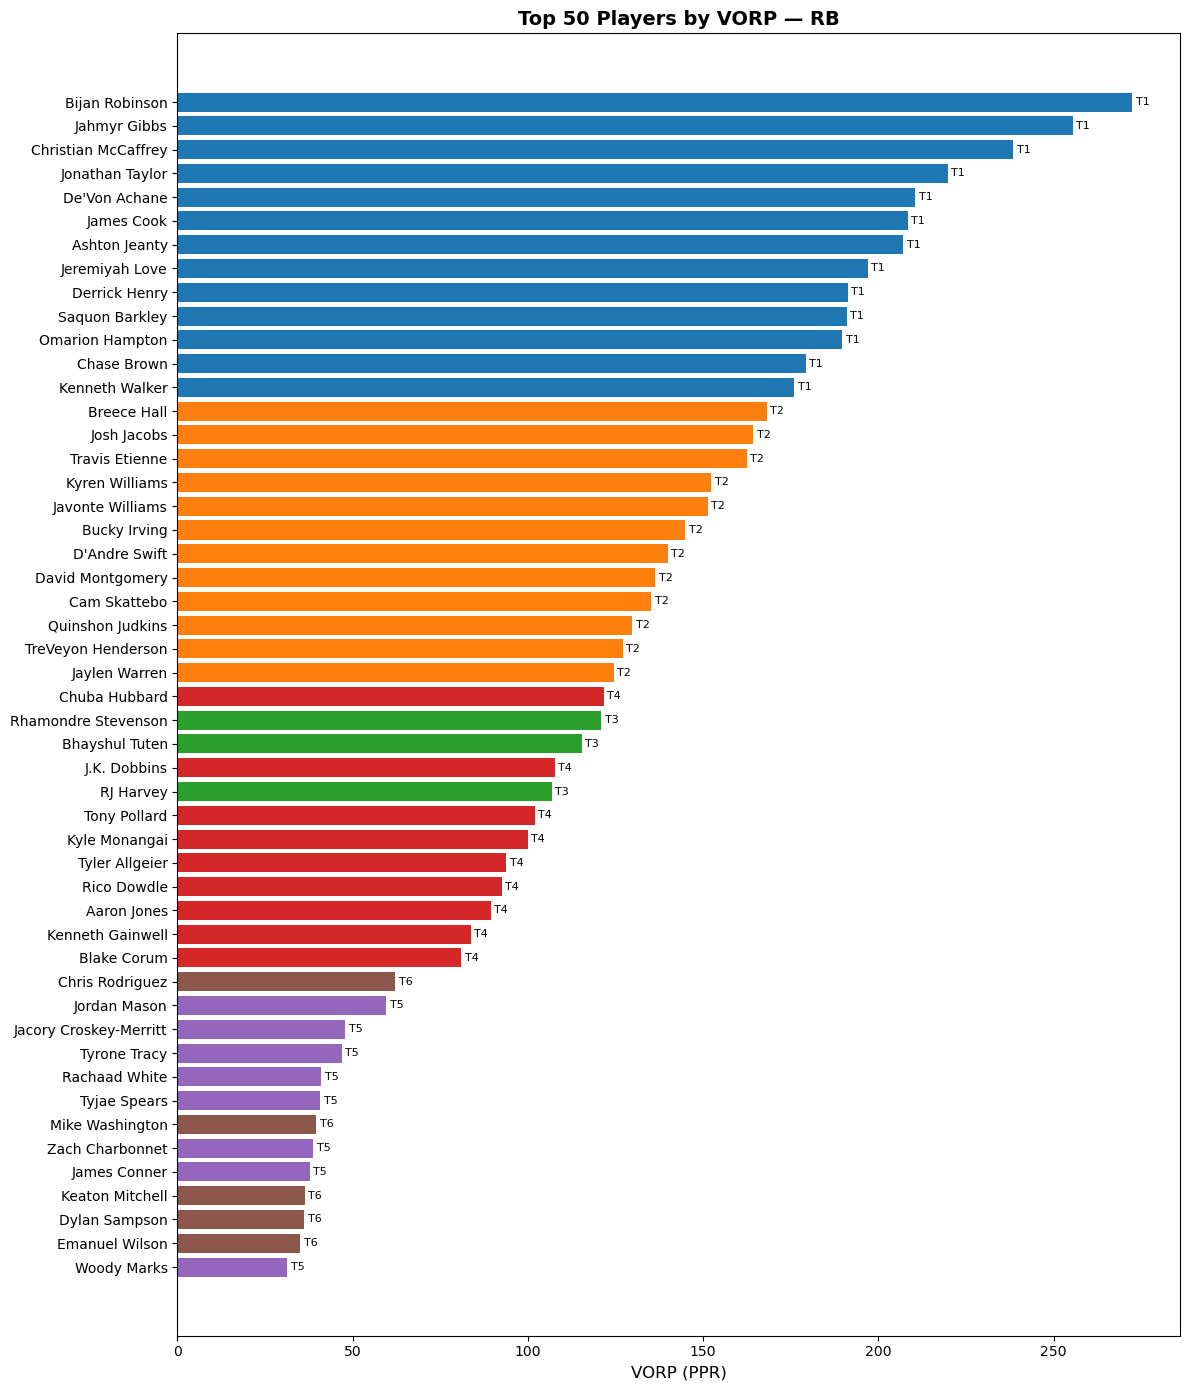

In [8]:
# ── Config ──────────────────────────────────────────────
n               = 50     # Number of players to show
position_filter = 'RB'   # Set to 'RB', 'WR', 'TE', 'QB' or None for all
# ────────────────────────────────────────────────────────

df_bar = df.copy()
if position_filter:
    df_bar = df_bar[df_bar['position'] == position_filter]

df_sorted = df_bar.sort_values('vorp_ppr', ascending=True).tail(n)

colors = sns.color_palette('tab10', n_colors=df['Tier'].nunique())
tier_colors = df_sorted['Tier'].map(lambda t: colors[int(t) - 1])

fig, ax = plt.subplots(figsize=(12, max(8, n * 0.28)))
bars = ax.barh(df_sorted['full_name'], df_sorted['vorp_ppr'], color=tier_colors)

for bar, tier in zip(bars, df_sorted['Tier']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'T{int(tier)}', va='center', fontsize=8)

ax.set_xlabel('VORP (PPR)', fontsize=12)
ax.set_title(
    f'Top {n} Players by VORP — {position_filter if position_filter else "All Positions"}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 9. Visualization — VORP Drop-off Line Chart

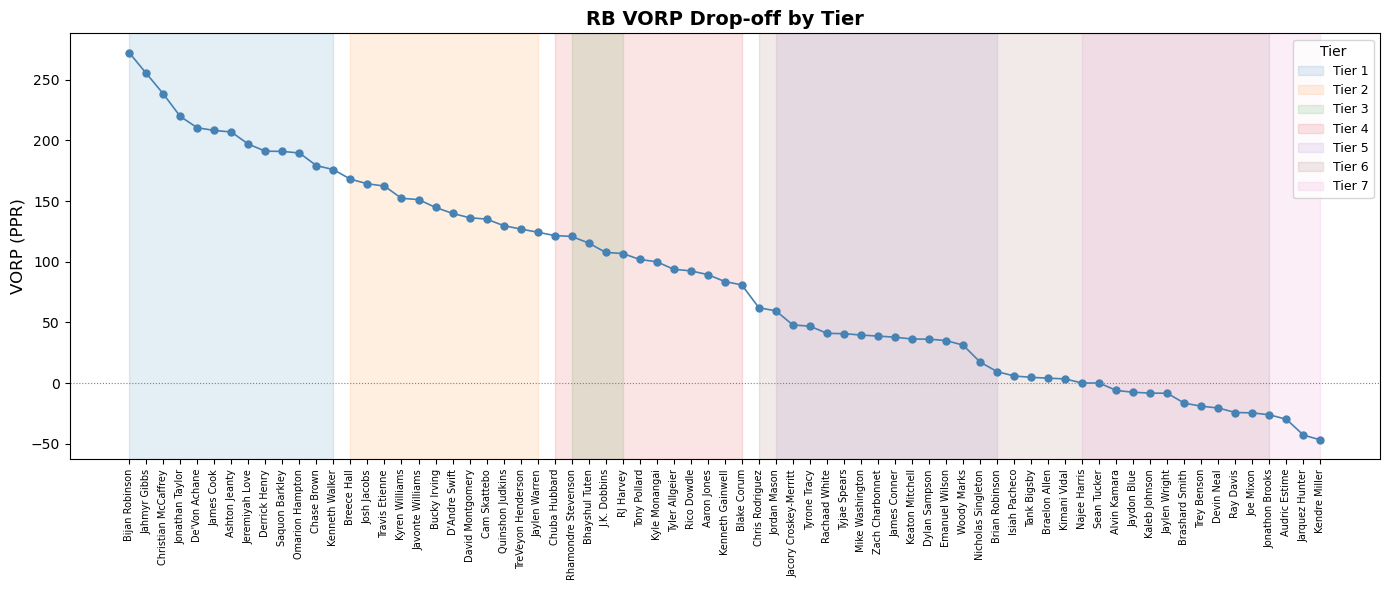

In [9]:
# ── Config ──────────────────────────────────────────────
position_filter = 'RB'   # Best used per position — set to 'RB', 'WR', 'TE', 'QB'
# ────────────────────────────────────────────────────────

df_line = df[df['position'] == position_filter].sort_values('vorp_ppr', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_line.index, df_line['vorp_ppr'], marker='o', linewidth=1.2,
        markersize=5, color='steelblue')

tier_palette = sns.color_palette('tab10', n_colors=df_line['Tier'].nunique())
for tier in sorted(df_line['Tier'].unique()):
    tier_idx = df_line[df_line['Tier'] == tier].index
    if len(tier_idx):
        ax.axvspan(tier_idx.min(), tier_idx.max(), alpha=0.12,
                   color=tier_palette[int(tier) - 1], label=f'Tier {int(tier)}')

ax.set_xticks(df_line.index)
ax.set_xticklabels(df_line['full_name'], rotation=90, fontsize=7)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_ylabel('VORP (PPR)', fontsize=12)
ax.set_title(f'{position_filter} VORP Drop-off by Tier', fontsize=14, fontweight='bold')
ax.legend(title='Tier', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Player Lookup

In [10]:
# ── Config ──────────────────────────────────────────────
player_name = "Warren"   # Exact name or partial string
# ────────────────────────────────────────────────────────

result = df[df['full_name'].str.contains(player_name, case=False)]
result[['full_name', 'position', 'adp_ppr', 'vorp_ppr', 'Tier',
        'residual_iso', 'rank_iso', 'Round']]

,full_name,position,adp_ppr,vorp_ppr,Tier,residual_iso,rank_iso,Round
65,Jaylen Warren,RB,74.8,124.4,2,0.0,29.0,7
52,Tyler Warren,TE,57.4,81.1,3,0.0,13.0,5


## 11. Close Connection

In [11]:
conn.close()
print('Database connection closed.')

Database connection closed.
